In [1]:
# ========================================
#  环境初始化：激活当前目录的项目环境
#  并根据 Manifest.toml 安装所需依赖包

import Pkg; Pkg.activate(@__DIR__); Pkg.instantiate()

  Activating project at `c:\Users\17978\Documents\New project\OCRL\lecture-notebooks\Lecture 2`


In [19]:
# ========================================
#  导入依赖包
#  - LinearAlgebra: 线性代数（eigvals, norm 等）
#  - PyPlot:        matplotlib 绘图
#  - ForwardDiff:   自动微分（Jacobian）

using LinearAlgebra
using PyPlot
using ForwardDiff

In [ ]:
# ========================================
#  单摆连续时间动力学方程 (ODE)
#  状态 x = [theta, thetad]（角度, 角速度）
#  动力学: thetadd = -(g/l) * sin(theta)
#  返回:  xdot = [thetad, thetadd]
# ========================================

function pendulum_dynamics(x)
    l = 1.0
    g = 9.81
    
    theta = x[1]
    thetad = x[2]  # theta_dot (角速度)
    
    thetadd = -(g/l)*sin(theta)  # theta_ddot (角加速度)
    
    return [thetad; thetadd]
end

pendulum_dynamics (generic function with 1 method)

In [20]:
# ========================================
#  显式前向 Euler 积分器
#  x_{k+1} = x_k + h·f(x_k)
#  参数:
#    fun - 动力学函数
#    x0  - 初始状态
#    Tf  - 仿真总时长
#    h   - 时间步长
#  返回: 状态历史矩阵 x_hist, 时间向量 t
#  x_{k+1} = x_k + h * f(x_k)

function pendulum_forward_euler(fun, x0, Tf, h)    
    t = Array(range(0,Tf,step=h))
    
    x_hist = zeros(length(x0),length(t))
    x_hist[:,1] .= x0
    
    for k = 1:(length(t)-1)
        x_hist[:,k+1] .= x_hist[:,k] + h*fun(x_hist[:,k])
    end
    
    return x_hist, t
end

pendulum_forward_euler (generic function with 1 method)

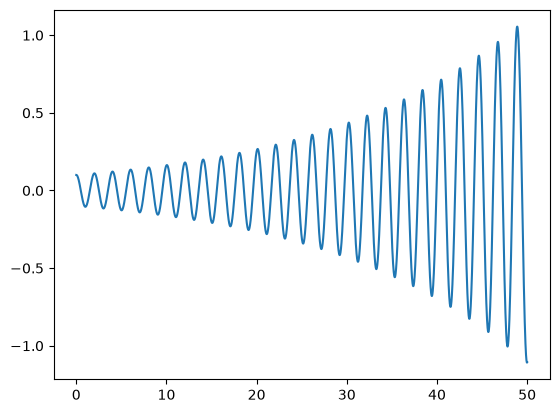

1-element Vector{PyCall.PyObject}:
 PyObject <matplotlib.lines.Line2D object at 0x0000027F9E3291D0>

In [21]:
# ========================================
#  测试前向 Euler: 仿真 50 秒, 步长 0.01
#  画摆角 θ(t) 随时间的变化
#  注意: 前向 Euler 在长时间仿真下会数值发散 (能量不守恒)

x0 = [.1; 0]
x_hist1, t_hist1 = pendulum_forward_euler(pendulum_dynamics, x0, 50, .01)
plot(t_hist1, x_hist1[1,:])

In [6]:
# ========================================
#  前向 Euler 离散化后的 Jacobian 矩阵 A_d
#  原始连续 Jacobian A_c = [0 1; -g cosθ 0]
#  前向 Euler 离散化: A_d = I + h·A_c
#  解析结果: A_d = [1  h; -g·h·cos(θ0)  1]

function pendulum_euler_Ad(x0, h)
    g = 9.81
    Ad = [1 h; -g*h*cos(x0[1]) 1]
end

pendulum_euler_Ad (generic function with 1 method)

In [7]:
# ========================================
#  检验: 步长 h=0.001 时 A_d 的特征值
#  稳定判据: 特征值模长 |λ| < 1 则离散系统稳定
#  若 |λ| > 1，系统在平衡点附近发散

eigvals(pendulum_euler_Ad(0, 0.001))

2-element Vector{ComplexF64}:
 1.0 - 0.0031320919526731652im
 1.0 + 0.0031320919526731652im

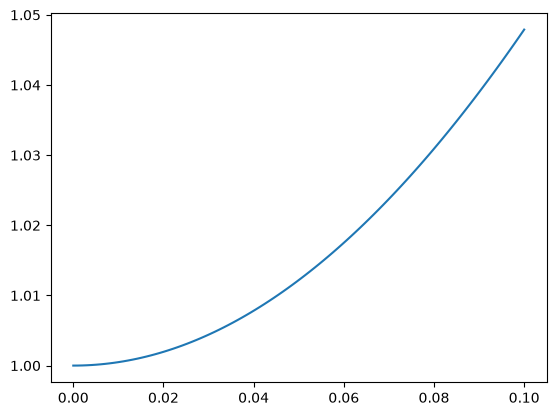

1-element Vector{PyCall.PyObject}:
 PyObject <matplotlib.lines.Line2D object at 0x0000027F9DF31310>

In [8]:
# ========================================
#  谱半径分析: 前向 Euler 稳定性 vs 步长 h
#  - 对每个步长 h，计算 A_d 的特征值
#  - 取最大模长 (谱半径 ρ = max|λ(A_d)|)
#  - 画 ρ(h) 曲线
#  结论: 步长越大 → ρ 越大 → 稳定性越差
#  当 ρ > 1 时，数值解在平衡点附近发散 (blows up)
#  讲义核心结论: Never use Forward Euler!

eignorm = zeros(100)
h = LinRange(0,0.1,100)
for k = 1:length(eignorm)
    eignorm[k] = max(norm.(eigvals(pendulum_euler_Ad([0;0], h[k])))...)
end
plot(h,eignorm)

In [9]:
# ========================================
#  RK4 (四阶 Runge-Kutta) 单步积分
#  经典 4 阶公式:
#    k1 = f(x_k)
#    k2 = f(x_k + h/2·k1)
#    k3 = f(x_k + h/2·k2)
#    k4 = f(x_k + h·k3)
#    x_{k+1} = x_k + h/6·(k1 + 2k2 + 2k3 + k4)
#  相比前向 Euler (一阶)，RK4 有四阶局部截断误差
#  精度大幅提升，能量行为好得多

function fd_pendulum_rk4(xk, h)
    f1 = pendulum_dynamics(xk)
    f2 = pendulum_dynamics(xk + 0.5*h*f1)
    f3 = pendulum_dynamics(xk + 0.5*h*f2)
    f4 = pendulum_dynamics(xk + h*f3)
    return xk + (h/6.0)*(f1 + 2*f2 + 2*f3 + f4)
end

fd_pendulum_rk4 (generic function with 1 method)

In [10]:
# ========================================
#  RK4 仿真循环: 逐时间步调用 fd_pendulum_rk4

function pendulum_rk4(fun, x0, Tf, h)    
    t = Array(range(0,Tf,step=h))
    
    x_hist = zeros(length(x0),length(t))
    x_hist[:,1] .= x0
    
    for k = 1:(length(t)-1)
        x_hist[:,k+1] .= fd_pendulum_rk4(x_hist[:,k], h)
    end
    
    return x_hist, t
end

pendulum_rk4 (generic function with 1 method)

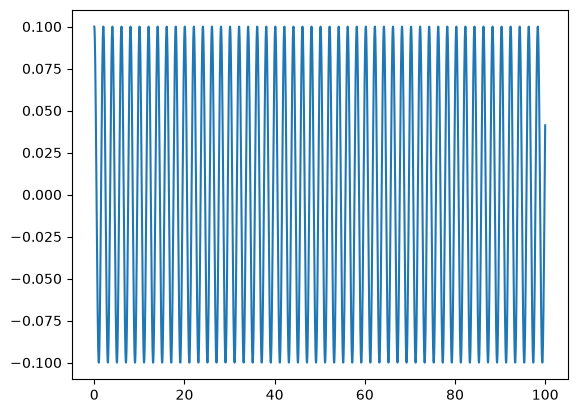

1-element Vector{PyCall.PyObject}:
 PyObject <matplotlib.lines.Line2D object at 0x0000027F9DF9BC50>

In [11]:
# ========================================
#  测试 RK4: 仿真 100 秒 (比前向 Euler 更长)
#  RK4 精度远超前向 Euler，长时间仿真不漂移
#  对比: 前向 Euler 50 秒就发散，RK4 100 秒仍稳定

x0 = [.1; 0]
x_hist2, t_hist2 = pendulum_rk4(pendulum_dynamics, x0, 100, 0.01)
plot(t_hist2, x_hist2[1,:])

In [12]:
# ========================================
#  RK4 离散化后的 Jacobian 矩阵
#  不同于前向 Euler 的解析公式，RK4 的 A_d 无简单闭式解
#  因此用 ForwardDiff.jl 自动微分:
#    A_d = ∂(x_{k+1})/∂(x_k) 在平衡点 [0;0] 处求值
#  ForwardDiff.jacobian 自动计算数值 Jacobian
#  然后计算特征值模长，检验稳定性

using ForwardDiff
Ad = ForwardDiff.jacobian(x -> fd_pendulum_rk4(x, 0.01), [0; 0])
norm.(eigvals(Ad))

2-element Vector{Float64}:
 0.9999999999934447
 0.9999999999934447

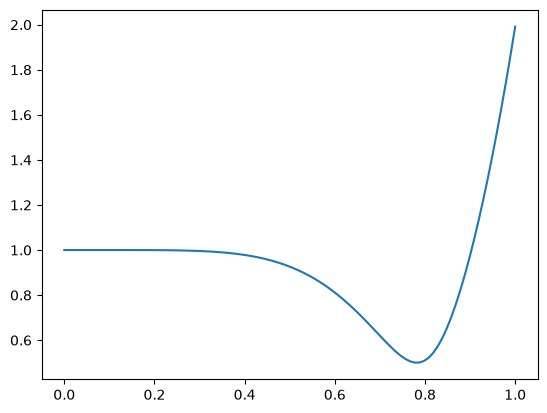

1-element Vector{PyCall.PyObject}:
 PyObject <matplotlib.lines.Line2D object at 0x0000027F9DCCAFD0>

In [13]:
# ========================================
#  谱半径分析: RK4 稳定性 vs 步长 h
#  与前向 Euler 对比:
#  - 前向 Euler 谱半径随 h 快速增长，很快 > 1
#  - RK4 谱半径对 h 更不敏感，稳定范围大得多
#  步长范围扩大到 h ∈ [0, 1] (前向 Euler 只能到 0.1)
#  讲义核心结论: Use RK4 instead!

eignorm = zeros(100)
h = LinRange(0,1,100)
for k = 1:length(eignorm)
    eignorm[k] = max(norm.(eigvals(ForwardDiff.jacobian(x -> fd_pendulum_rk4(x, h[k]), [0; 0])))...)
end
plot(h,eignorm)

In [14]:
# ========================================
#  隐式后向 Euler 积分器
#  x_{k+1} = x_k + h·f(x_{k+1}) (右端依赖未知的 x_{k+1})
#  每步需要求解隐式方程 → 用不动点迭代 (fixed-point)
#  算法: 重复 x_{k+1} ← x_k + h·f(x_{k+1}) 直到收敛
#  优点: 无条件稳定 (A-stable)，大步长不炸
#  缺点: 每步要迭代多次，计算量大；精度仅一阶
#  收敛判据: ||x_new - x_old|| < 1e-8

function pendulum_backward_euler(fun, x0, Tf, dt)
    t = Array(range(0,Tf,step=dt))
    
    x_hist = zeros(length(x0),length(t))
    x_hist[:,1] .= x0
    
    for k = 1:(length(t)-1)
        e = 1
        x_hist[:,k+1] = x_hist[:,k]
        while e > 1e-8
            xn = x_hist[:,k] + dt.*fun(x_hist[:,k+1])
            e = norm(xn - x_hist[:,k+1])
            x_hist[:,k+1] .= xn
        end
    end
    
    return x_hist, t
end

pendulum_backward_euler (generic function with 1 method)

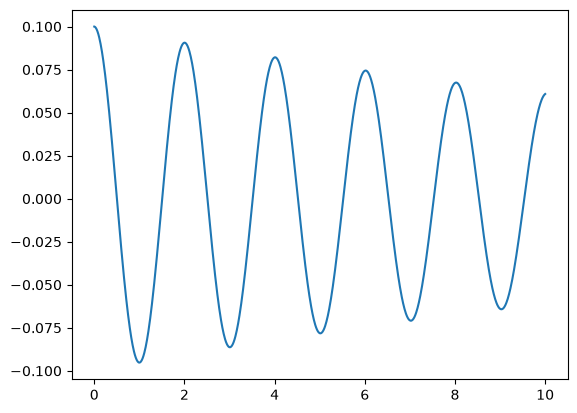

1-element Vector{PyCall.PyObject}:
 PyObject <matplotlib.lines.Line2D object at 0x0000027F9DD49D10>

In [15]:
# ========================================
#  测试后向 Euler: 仿真 10 秒
#  后向 Euler 数值稳定，能量不增长
#  但注意: 隐式方法会引入数值阻尼，能量反而衰减
#  对比: 前向 Euler 能量爆炸，RK4 能量守恒最好
#  后向 Euler 适合刚性问题 (stiff ODE)

x0 = [.1; 0]
x_hist3, t_hist3 = pendulum_backward_euler(pendulum_dynamics, x0, 10, 0.01)
plot(t_hist3, x_hist3[1,:])